In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

# If running in a Jupyter environment, this ensures inline plotting
%matplotlib inline

In [15]:
# --- Configuration ---
# Update this path to where your precomputed parquet file is located
FILE_PATH = "TreadmillEnergyDashboard/exported_pogensee/precomputed_poggensee.parquet"

# The target proxy column to predict (e.g., "mechanical_power" or "net_bio_cost_w")
TARGET_METRIC = "mechanical_power"

# The prefix for the 100 power bins to use as X (e.g., "ref_exo", "ref_sys", "ref_hum")
FEATURE_PREFIX = "ref_sys"

# Where to save the output plot on the headless node
PLOT_SAVE_PATH = f"{FEATURE_PREFIX}_to_{TARGET_METRIC}_sensitivity.png"

In [16]:
print(f"Loading data from {FILE_PATH}...")
df = pd.read_parquet(FILE_PATH)

# Drop rows containing NaNs in our target to prevent modeling faults
df = df.dropna(subset=[TARGET_METRIC])
if len(df) == 0:
    raise ValueError(f"No valid rows found after filtering for target '{TARGET_METRIC}'.")

print(f"Found {len(df)} valid samples.")

# Extract 100-dimensional X vector from data columns
feature_cols = [f"{FEATURE_PREFIX}_w_{i:02d}" for i in range(100)]
try:
    X = df[feature_cols].values
except KeyError:
    raise KeyError(f"Could not find columns matching '{FEATURE_PREFIX}_w_XX'")

Y = df[TARGET_METRIC].values

# Standardize X for Ridge regression so varying amplitudes don't skew the penalty
scaler_x = StandardScaler()
X_scaled = scaler_x.fit_transform(X)

Loading data from TreadmillEnergyDashboard/exported_pogensee/precomputed_poggensee.parquet...
Found 870 valid samples.


In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV

# --- 1. Dimensionality Reduction ---
num_components = 8
pca = PCA(n_components=num_components)
X_pca = pca.fit_transform(X_scaled)

variance_explained = np.sum(pca.explained_variance_ratio_) * 100
print(f"PCA ({num_components} components) explains {variance_explained:.1f}% of the variance.")

# --- 2. Non-Linear Modeling Pipeline ---
# We use PolynomialFeatures to capture quadratic effects and interactions between PCA shapes
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', RidgeCV(alphas=np.logspace(-3, 5, 100), store_cv_results=True))
])

print(f"Fitting model: Y = {TARGET_METRIC} | X = Quadratic interactions of {num_components} PCs")
poly_model.fit(X_pca, Y)

score = poly_model.score(X_pca, Y)
print(f"New Model Fit R^2: {score:.3f}")

PCA (8 components) explains 83.6% of the variance.
Fitting model: Y = mechanical_power | X = Quadratic interactions of 8 PCs
New Model Fit R^2: 0.671


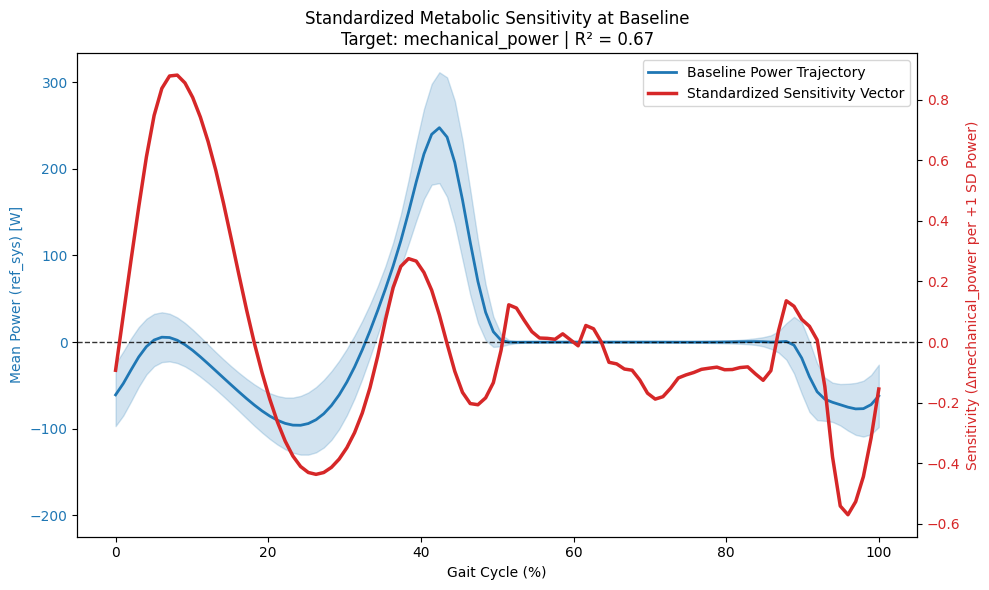

In [34]:
def get_local_sensitivity(Z_state, return_standardized=True):
    """Calculates the local derivative of the model wrt the 100 power bins."""
    epsilon = 1e-4
    grad_Z = np.zeros(num_components)
    
    # 1. Numerical derivative in PCA space
    for i in range(num_components):
        Z_plus = Z_state.copy()
        Z_plus[i] += epsilon
        Z_minus = Z_state.copy()
        Z_minus[i] -= epsilon
        
        y_plus = poly_model.predict([Z_plus])[0]
        y_minus = poly_model.predict([Z_minus])[0]
        grad_Z[i] = (y_plus - y_minus) / (2 * epsilon)
        
    # 2. Map gradient back.
    # pca.components_.T @ grad_Z gives us dY/d(Scaled_X)
    grad_X_scaled = pca.components_.T @ grad_Z
    
    if return_standardized:
        # Returns effect on metabolics per +1 Standard Deviation change in Power
        # This naturally suppresses regions where variance is ~0
        return grad_X_scaled
    else:
        # Returns raw effect (dividing by std dev), prone to exploding in flat regions
        return grad_X_scaled / scaler_x.scale_

# Evaluate standardized sensitivity right at the baseline
baseline_sensitivity = get_local_sensitivity(np.zeros(num_components), return_standardized=True)

fig, ax1 = plt.subplots(figsize=(10, 6))
time_pct = np.linspace(0, 100, 100)

color_power = 'tab:blue'
ax1.set_xlabel('Gait Cycle (%)')
ax1.set_ylabel(f'Mean Power ({FEATURE_PREFIX}) [W]', color=color_power)
ax1.plot(time_pct, mean_power_profile, color=color_power, linewidth=2, label="Baseline Power Trajectory")
ax1.fill_between(time_pct, 
                 mean_power_profile - std_power_profile, 
                 mean_power_profile + std_power_profile, 
                 color=color_power, alpha=0.2)
ax1.tick_params(axis='y', labelcolor=color_power)

ax2 = ax1.twinx()  
color_weights = 'tab:red'
# Note the updated y-label to reflect the new mathematical meaning
ax2.set_ylabel(f'Sensitivity (Δ{TARGET_METRIC} per +1 SD Power)', color=color_weights)
ax2.plot(time_pct, baseline_sensitivity, color=color_weights, linewidth=2.5, linestyle='-', 
         label="Standardized Sensitivity Vector")
ax2.tick_params(axis='y', labelcolor=color_weights)

# Align Zeros
ylim1 = ax1.get_ylim()
ylim2 = ax2.get_ylim()
frac_zero_1 = -ylim1[0] / (ylim1[1] - ylim1[0])
frac_zero_2 = -ylim2[0] / (ylim2[1] - ylim2[0])

if frac_zero_1 > frac_zero_2:
    ax2.set_ylim(ylim2[1] - (ylim2[1] / (1 - frac_zero_1)), ylim2[1])
else:
    ax1.set_ylim(ylim1[1] - (ylim1[1] / (1 - frac_zero_2)), ylim1[1])

ax1.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.8)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title(f"Standardized Metabolic Sensitivity at Baseline\nTarget: {TARGET_METRIC} | R² = {score:.2f}")
plt.tight_layout()
plt.savefig("baseline_sensitivity_standardized.png", dpi=300)
plt.show()

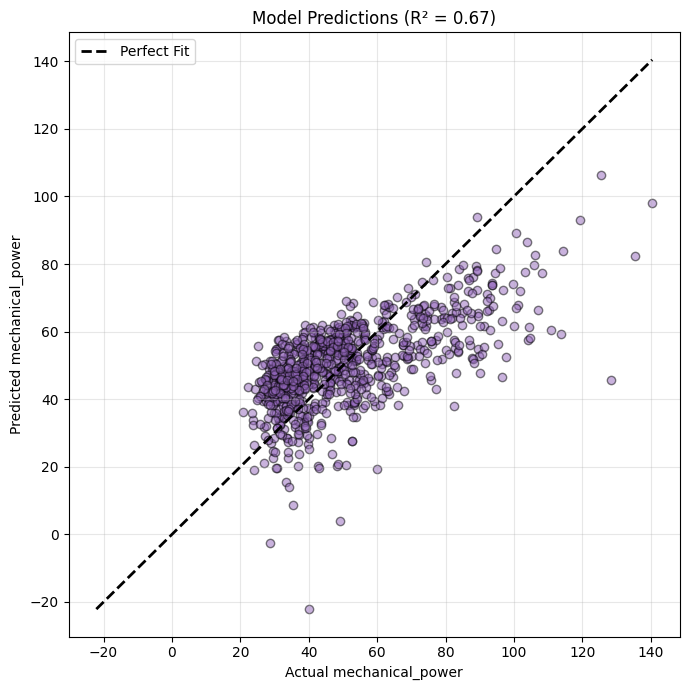

In [25]:
# --- Cell 6: Actual vs Predicted Scatter ---
Y_pred = model.predict(X_pca)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(Y, Y_pred, alpha=0.5, color='tab:purple', edgecolor='k')

# Plot the perfect 1:1 prediction line
min_val = min(Y.min(), Y_pred.min())
max_val = max(Y.max(), Y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Fit')

ax.set_xlabel(f"Actual {TARGET_METRIC}")
ax.set_ylabel(f"Predicted {TARGET_METRIC}")
ax.set_title(f"Model Predictions (R² = {score:.2f})")
ax.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=300)
plt.show()

Generating dual-axis animation (54 frames)...
GIF successfully saved to: dynamic_sensitivity_descent_standardized.gif


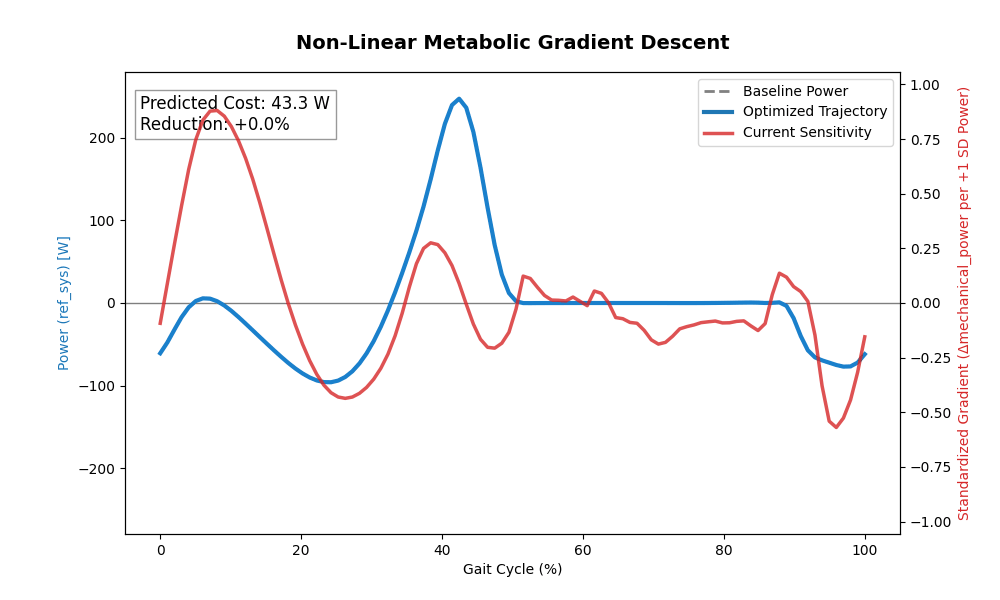

In [33]:
# --- Setup Animation Plot with Twin Axes ---
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.plot(time_pct, mean_power_raw, color='gray', linestyle='--', linewidth=2, label='Baseline Power')
ax1.axhline(0, color='black', linewidth=1, linestyle='-', alpha=0.5)

(line_power,) = ax1.plot(time_pct, mean_power_raw, color='tab:blue', linewidth=3, label='Optimized Trajectory')
(line_sens,) = ax2.plot(time_pct, baseline_sensitivity, color='tab:red', linewidth=2.5, alpha=0.8, label='Current Sensitivity')

title_text = ax1.text(0.5, 1.05, '', transform=ax1.transAxes, ha='center', fontsize=14, weight='bold')
metrics_text = ax1.text(0.02, 0.95, '', transform=ax1.transAxes, va='top', fontsize=12, 
                       bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

ax1.set_xlabel('Gait Cycle (%)')
ax1.set_ylabel(f'Power ({FEATURE_PREFIX}) [W]', color='tab:blue')
ax2.set_ylabel(f'Standardized Gradient (Δ{TARGET_METRIC} per +1 SD Power)', color='tab:red')

ax1.set_ylim(min_y, max_y)

max_sens = np.max(np.abs(baseline_sensitivity)) * 1.2
ax2.set_ylim(-max_sens, max_sens)

# Align Zeros
ylim1 = ax1.get_ylim()
ylim2 = ax2.get_ylim()
frac_zero_1 = -ylim1[0] / (ylim1[1] - ylim1[0])
frac_zero_2 = -ylim2[0] / (ylim2[1] - ylim2[0])
if frac_zero_1 > frac_zero_2:
    ax2.set_ylim(ylim2[1] - (ylim2[1] / (1 - frac_zero_1)), ylim2[1])
else:
    ax1.set_ylim(ylim1[1] - (ylim1[1] / (1 - frac_zero_2)), ylim1[1])

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

def update_dual(frame_idx):
    Z_frame = path_Z[frame_idx]
    Y_frame = path_Y[frame_idx]
    pct_change = ((Y_frame - Y_base) / Y_base) * 100
    
    # 1. Update Power Trajectory
    X_scaled = pca.inverse_transform(Z_frame)
    X_raw = scaler_x.inverse_transform([X_scaled])[0]
    line_power.set_ydata(X_raw)
    
    # 2. Update Sensitivity Vector (Standardized)
    current_sensitivity = get_local_sensitivity(Z_frame, return_standardized=True)
    line_sens.set_ydata(current_sensitivity)
    
    title_text.set_text("Non-Linear Metabolic Gradient Descent")
    metrics_text.set_text(f"Predicted Cost: {Y_frame:.1f} W\nReduction: {pct_change:+.1f}%")
    
    intensity = min(1.0, abs(pct_change) / (target_reduction_pct * 100))
    line_power.set_color((0.1, 0.5 + 0.4*intensity, 0.8 - 0.4*intensity)) 
    
    return line_power, line_sens, title_text, metrics_text

print(f"Generating dual-axis animation ({total_frames} frames)...")
ani_dual = animation.FuncAnimation(fig, update_dual, frames=total_frames, blit=True)

gif_dual_path = "dynamic_sensitivity_descent_standardized.gif"
ani_dual.save(gif_dual_path, writer='pillow', fps=15)
print(f"GIF successfully saved to: {gif_dual_path}")

plt.close(fig) 
Image(filename=gif_dual_path)